# 1. DPD Scoring and Data Overview

**Dataset:** Genome-scale Perturb-seq — Primary Human CD4+ T Cells (Zhu, Dann et al. 2025)  
**Reference:** https://virtualcellmodels.cziscience.com/dataset/genome-scale-tcell-perturb-seq

**Stimulation vector (v_stim):** For Stim8hr and Stim48hr, computed here as the mean log1p fold-change between NTC-Stim and NTC-Rest cells across donors. Significance is tested with a one-sample t-test across donors; only genes significant at p < 0.05 are retained. For Rest, v_stim cannot be derived from NTC files (Rest IS the baseline). Instead, v_stim is loaded from the Stim8hr run output, so that DPD scores remain on the same activation axis and are comparable across all three conditions.

**DPD scoring**

For every single-gene CRISPRi knockdown in DE_stats, we compute a DPD score, which is the dot product between the perturbation's transcriptional effect vector and a reference direction vector. Two scores are computed per perturbation (and then normalised by dividing by the L2 norm of the respective reference vector):
- **DPD_stim**: alignment with v_stim, the NTC Stim-vs-Rest transcriptional shift. Positive = knockdown enhances activation; negative = suppresses it.
- **DPD_btla**: alignment with v_btla, the BTLA-vs-TCR inhibitory axis from bulk data. Loaded from Notebook 0 output. Skipped for Rest (no matched BTLA timepoint).

## Contents
1. Configuration
2. Load data
3. QC: cells per perturbation and NTC sparsity
4. Compute or load v_stim
5. Load v_btla
6. Align vectors and build perturbation matrix
7. Compute and normalise DPD scores
8. Figures
9. Save


### 1. Configuration

In [1]:
import os
print(f'Working directory: {os.getcwd()}')

Working directory: /mnt/R0/Projects/POIAZ/Ilaria/Scripts


In [2]:
# Edit these to change condition
CONDITION = 'Rest'  # 'Rest', 'Stim8hr', 'Stim48hr'
DONORS = ['D1', 'D2', 'D3', 'D4']
donors_tag = '_'.join(DONORS)
run_tag = f'{CONDITION}_{donors_tag}'

# Paths
DATA_DIR = '../Data'
DESTATS_PATH = '../Data/GWCD4i.DE_stats.h5ad'
REF_DIR = '../Results/ref' # Notebook 0 outputs
BTLA_TIMEPOINT = '4h'  # must match what was used in Notebook 0

# For Rest, v_stim is loaded from the Stim8hr run rather than computed from NTC files.
# This ensures all three conditions share the same activation axis for DPD scoring.
# VSTIM_REF_CONDITION is only used when CONDITION == 'Rest'.
VSTIM_REF_CONDITION = 'Stim8hr'

OUT_DIR = f'../Results/{CONDITION}'
os.makedirs(OUT_DIR, exist_ok=True)

# Parameters
P_THRESHOLD = 0.05
LOW_CELL_THRESHOLD = 10 # flag perturbations below this cell count in QC
TOP_N_BARS = 15 # genes shown in bar charts

print(f'Condition: {CONDITION}')
print(f'Donors: {DONORS}')
print(f'run_tag: {run_tag}')
print(f'Out dir: {OUT_DIR}')
if CONDITION == 'Rest':
    print(f'v_stim will be loaded from: ../Results/{VSTIM_REF_CONDITION}/')


Condition: Rest
Donors: ['D1', 'D2', 'D3', 'D4']
run_tag: Rest_D1_D2_D3_D4
Out dir: ../Results/Rest
v_stim will be loaded from: ../Results/Stim8hr/


In [3]:
import numpy as np
import pandas as pd
import anndata
import scipy.sparse
import matplotlib.pyplot as plt
from scipy import stats

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
print('Packages loaded.')


Packages loaded.


### 2. Load Data

DE_stats is opened in backed mode: only the obs metadata is loaded into RAM; the expression layers are read from disk on demand. NTC files are loaded only when CONDITION != 'Rest', since v_stim for Rest is loaded from a prior run rather than recomputed.


In [4]:
DE_stats = anndata.read_h5ad(DESTATS_PATH, backed='r')
print(f'DE_stats: {DE_stats.shape}  (perturbations × genes)')
print(f'Layers: {list(DE_stats.layers.keys())}')

# NTC files are only needed to compute v_stim, which requires a Stim vs Rest comparison.
# For Rest, there is no such comparison to make (Rest IS the NTC baseline), so we skip loading.
if CONDITION != 'Rest':
    stim_adatas = []
    rest_adatas = []
    for donor in DONORS:
        stim_path = os.path.join(DATA_DIR, f'{donor}_{CONDITION}.NTC.h5ad')
        rest_path = os.path.join(DATA_DIR, f'{donor}_Rest.NTC.h5ad')
        stim_adatas.append(anndata.read_h5ad(stim_path))
        rest_adatas.append(anndata.read_h5ad(rest_path))
        print(f'{donor}: stim={stim_adatas[-1].shape}, rest={rest_adatas[-1].shape}')
else:
    print('Rest condition: skipping NTC file loading (v_stim will be loaded from Stim8hr run).')


DE_stats: (33983, 10282)  (perturbations × genes)
Layers: ['adj_p_value', 'baseMean', 'lfcSE', 'log_fc', 'p_value', 'zscore']
Rest condition: skipping NTC file loading (v_stim will be loaded from Stim8hr run).


### 3. QC: Cells per Perturbation and NTC Sparsity

In [5]:
# Confirm all perturbations are single-gene (no multi-gene targets)
n_multi = DE_stats.obs['target_contrast_gene_name'].str.contains(r'[_+&,;/]', regex=True, na=False).sum()
print(f'Total perturbation rows: {len(DE_stats.obs):,}')
print(f'Multi-gene entries: {n_multi}')
if n_multi == 0:
    print('All entries are single-gene perturbations.')
else:
    print(f'WARNING: {n_multi} multi-gene entries found, inspect before proceeding')


Total perturbation rows: 33,983
Multi-gene entries: 0
All entries are single-gene perturbations.


Cells per perturbation
  Mean: 603.5
  Median: 539.0
  Min: 17
  Max: 11510
  < 10 cells: 0 (0.0%)


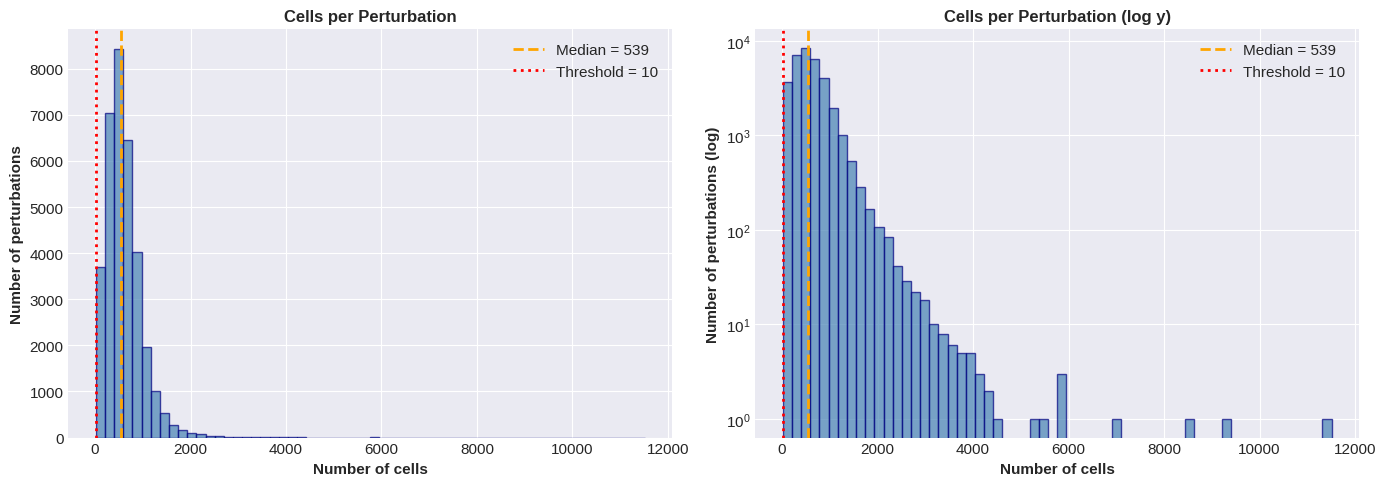

Saved: ../Results/Rest/qc_cells_per_perturbation_Rest_D1_D2_D3_D4.png


In [6]:
cell_counts = DE_stats.obs['n_cells_target'].dropna()
n_low = (cell_counts < LOW_CELL_THRESHOLD).sum()

print(f'Cells per perturbation')
print(f'  Mean: {cell_counts.mean():.1f}')
print(f'  Median: {cell_counts.median():.1f}')
print(f'  Min: {cell_counts.min():.0f}')
print(f'  Max: {cell_counts.max():.0f}')
print(f'  < {LOW_CELL_THRESHOLD} cells: {n_low} ({100*n_low/len(cell_counts):.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, logy in zip(axes, [False, True]):
    ax.hist(cell_counts, bins=60, color='steelblue', edgecolor='navy', alpha=0.7)
    ax.axvline(cell_counts.median(), color='orange', lw=2, linestyle='--',
               label=f'Median = {cell_counts.median():.0f}')
    ax.axvline(LOW_CELL_THRESHOLD, color='red', lw=2, linestyle=':',
               label=f'Threshold = {LOW_CELL_THRESHOLD}')
    ax.set_xlabel('Number of cells', fontsize=11, fontweight='bold')
    ax.set_ylabel('Number of perturbations' + (' (log)' if logy else ''), fontsize=11, fontweight='bold')
    ax.set_title('Cells per Perturbation' + (' (log y)' if logy else ''), fontsize=12, fontweight='bold')
    ax.legend()
    if logy:
        ax.set_yscale('log')
plt.tight_layout()
p = os.path.join(OUT_DIR, f'qc_cells_per_perturbation_{run_tag}.png')
plt.savefig(p, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')


In [7]:
# NTC sparsity check — only run when NTC files were loaded
if CONDITION != 'Rest':
    def _sparsity_stats(adatas, label):
        n_cells_total = 0
        n_genes = adatas[0].shape[1]
        nonzero_counts = np.zeros(n_genes, dtype=np.int64)
        allzero_mask = np.ones(n_genes, dtype=bool)
        for a in adatas:
            X = a.X
            if scipy.sparse.issparse(X):
                nz = np.asarray((X != 0).sum(axis=0)).ravel()
                az = np.asarray((X != 0).sum(axis=0)).ravel() == 0
            else:
                X = np.asarray(X)
                nz = (X != 0).sum(axis=0)
                az = nz == 0
            nonzero_counts += nz
            allzero_mask &= az
            n_cells_total += a.shape[0]
        n_allzero = allzero_mask.sum()
        mean_nonzero_frac = (nonzero_counts / n_cells_total).mean()
        print(f'{label} ({n_cells_total:,} cells, {n_genes:,} genes)')
        print(f'  All-zero genes: {n_allzero} ({100*n_allzero/n_genes:.1f}%)')
        print(f'  Mean non-zero/gene: {mean_nonzero_frac:.3f}')
        print()

    _sparsity_stats(stim_adatas, f'NTC-Stim ({CONDITION})')
    _sparsity_stats(rest_adatas, 'NTC-Rest')
else:
    print('Rest condition: NTC sparsity check skipped.')


Rest condition: NTC sparsity check skipped.


### 4. Compute or Load v_stim

For Stim8hr and Stim48hr: v_stim is computed as the mean log1p fold-change (Stim − Rest) across NTC cells, averaged across donors. Only genes with consistent directional change across donors (raw p < 0.05, one-sample t-test) are retained.

For Rest: v_stim cannot be computed from NTC files because Rest IS the NTC baseline — the difference would be zero by construction. Instead, v_stim is loaded from the saved Stim8hr output. This preserves the biological meaning of the activation axis and makes DPD scores directly comparable across all three conditions.


In [8]:
def mean_log1p(adata):
    X = adata.X
    if scipy.sparse.issparse(X):
        X = X.toarray()
    X = X.astype(np.float32)
    totals = X.sum(axis=1, keepdims=True)
    totals = np.where(totals == 0, 1.0, totals)
    return np.log1p(X / totals * 1e4).mean(axis=0)


In [9]:
if CONDITION != 'Rest':
    # Standard path: compute v_stim from NTC files for this condition
    donor_stim_means = np.stack([mean_log1p(a) for a in stim_adatas]) # (n_donors, n_genes)
    donor_rest_means = np.stack([mean_log1p(a) for a in rest_adatas])
    donor_logfc = donor_stim_means - donor_rest_means
    mean_logfc = donor_logfc.mean(axis=0)
    print(f'Computed logFC for {len(DONORS)} donors, {mean_logfc.shape[0]:,} genes')
    print(f'Mean logFC range: [{mean_logfc.min():.3f}, {mean_logfc.max():.3f}]')

    if len(DONORS) >= 3:
        _, p_vals = stats.ttest_1samp(donor_logfc, popmean=0, axis=0)
        p_adj = p_vals.astype(np.float32)
        print(f'Significance: one-sample t-test, raw p (n={len(DONORS)}, df={len(DONORS)-1})')
    elif len(DONORS) == 2:
        _, p_vals = stats.ttest_rel(donor_stim_means, donor_rest_means, axis=0)
        p_adj = p_vals.astype(np.float32)
        print('Significance: paired t-test, raw p (n=2, df=1)')
    else:
        p_adj = np.where(mean_logfc != 0, 0.0, 1.0).astype(np.float32)
        print('Single donor, retaining all non-zero logFC genes')

    sig_mask = p_adj <= P_THRESHOLD
    v_stim = np.where(sig_mask, mean_logfc, 0.0).astype(np.float32)
    gene_ids_ntc = stim_adatas[0].var_names.values

    print(f'\nv_stim: {sig_mask.sum():,} significant genes ({100*sig_mask.mean():.1f}%)')
    print(f'v_stim range: [{v_stim.min():.3f}, {v_stim.max():.3f}]')
    print(f'v_stim L2 norm: {np.linalg.norm(v_stim):.4f}')

    if np.linalg.norm(v_stim) == 0:
        raise ValueError('v_stim is all zeros, check significance testing logic')

    # Free NTC data from memory — no longer needed
    del stim_adatas, rest_adatas, donor_stim_means, donor_rest_means, donor_logfc
    import gc; gc.collect()
    print('NTC data freed from memory.')

else:
    # Rest path: load v_stim from the Stim8hr run.
    # The Stim8hr v_stim is saved in the aligned common-gene space (columns = ensembl_id).
    # We load it and reconstruct the arrays that downstream cells expect:
    #   v_stim        — values for significant genes, zeros elsewhere (full NTC gene space)
    #   gene_ids_ntc  — gene IDs corresponding to v_stim entries
    #   sig_mask      — boolean mask of significant genes
    #   p_adj         — p-values (loaded from file; used in the Save cell)
    vstim_ref_tag = f'{VSTIM_REF_CONDITION}_{"_".join(DONORS)}'
    vstim_ref_path = os.path.join('..', 'Results', VSTIM_REF_CONDITION, f'v_stim_{vstim_ref_tag}.csv')
    print(f'Rest condition: loading v_stim from {vstim_ref_path}')

    vstim_ref_df = pd.read_csv(vstim_ref_path)
    print(f'Loaded v_stim reference: {vstim_ref_df.shape[0]:,} genes')

    gene_ids_ntc = vstim_ref_df['ensembl_id'].values
    sig_mask = vstim_ref_df['significant'].values.astype(bool)
    p_adj = vstim_ref_df['p_adj'].values.astype(np.float32)
    v_stim = vstim_ref_df['logFC_sig'].values.astype(np.float32)

    print(f'v_stim: {sig_mask.sum():,} significant genes ({100*sig_mask.mean():.1f}%)')
    print(f'v_stim range: [{v_stim.min():.3f}, {v_stim.max():.3f}]')
    print(f'v_stim L2 norm: {np.linalg.norm(v_stim):.4f}')
    print(f'(Reference condition: {VSTIM_REF_CONDITION})')


Rest condition: loading v_stim from ../Results/Stim8hr/v_stim_Stim8hr_D1_D2_D3_D4.csv
Loaded v_stim reference: 10,282 genes
v_stim: 1,199 significant genes (11.7%)
v_stim range: [-1.249, 1.152]
v_stim L2 norm: 7.3412
(Reference condition: Stim8hr)


Perturbations in Rest: 11,287
Sig genes per perturbation; mean: 34.3, median: 2.0
Range: [0, 3967]


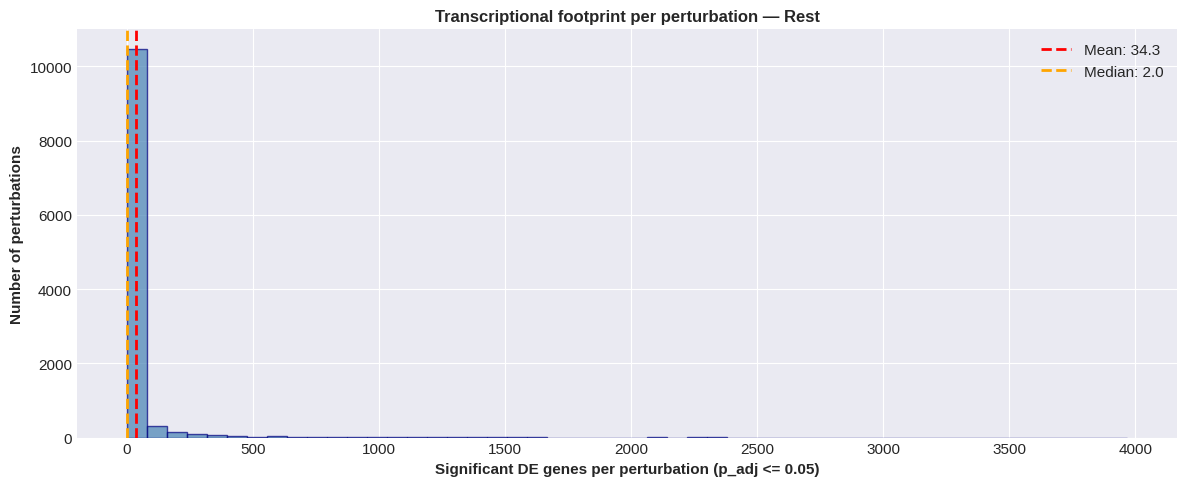

Saved: ../Results/Rest/qc_sig_genes_per_pert_Rest_D1_D2_D3_D4.png


In [10]:
# Distribution of significant DE genes per perturbation, useful QC before scoring
DE_stim = DE_stats[DE_stats.obs['culture_condition'] == CONDITION]

def get_dense(adata, layer):
    mat = adata.layers[layer]
    if scipy.sparse.issparse(mat):
        mat = mat.toarray()
    return mat.astype(np.float32)

p_adj_pert = get_dense(DE_stim, 'adj_p_value')
sig_gene_counts = ((p_adj_pert <= P_THRESHOLD) & (~np.isnan(p_adj_pert))).sum(axis=1)

print(f'Perturbations in {CONDITION}: {len(sig_gene_counts):,}')
print(f'Sig genes per perturbation; mean: {sig_gene_counts.mean():.1f}, median: {np.median(sig_gene_counts):.1f}')
print(f'Range: [{sig_gene_counts.min()}, {sig_gene_counts.max()}]')

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(sig_gene_counts, bins=50, color='steelblue', edgecolor='navy', alpha=0.7)
ax.axvline(sig_gene_counts.mean(), color='red', lw=2, linestyle='--', label=f'Mean: {sig_gene_counts.mean():.1f}')
ax.axvline(np.median(sig_gene_counts), color='orange', lw=2, linestyle='--', label=f'Median: {np.median(sig_gene_counts):.1f}')
ax.set_xlabel(f'Significant DE genes per perturbation (p_adj <= {P_THRESHOLD})', fontsize=11, fontweight='bold')
ax.set_ylabel('Number of perturbations', fontsize=11, fontweight='bold')
ax.set_title(f'Transcriptional footprint per perturbation — {CONDITION}', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
p = os.path.join(OUT_DIR, f'qc_sig_genes_per_pert_{run_tag}.png')
plt.savefig(p, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')


### 5. Load v_btla

v_btla was computed in Notebook 0 from the external BTLA bulk DEG data and saved to `Results/ref/`. Loading it here avoids recomputing it every condition run and ensures consistency across conditions. Skipped for Rest: the BTLA bulk experiment has no matched resting timepoint, so DPD_btla is not meaningful for this condition.


In [11]:
if CONDITION == 'Rest':
    # No matched BTLA timepoint for resting cells; DPD_btla is skipped for this condition.
    # btla_norm is set to nan so the Save cell can write a consistent summary row.
    v_btla_full = None
    btla_norm = np.nan
    gene_ids_de_stats = DE_stats.var_names.values
    print('Rest condition: skipping v_btla load. DPD_btla will not be computed.')
else:
    btla_path = os.path.join(REF_DIR, f'v_btla_{BTLA_TIMEPOINT}.csv')
    btla_df = pd.read_csv(btla_path)
    print(f'Loaded v_btla from: {btla_path}')
    print(f'Shape: {btla_df.shape}')

    # The vector is stored in DE_stats gene order (ensembl_id column = DE_stats var_names order)
    v_btla_full = btla_df['logFC_btla'].values.astype(np.float32)
    gene_ids_de_stats = DE_stats.var_names.values

    print(f'DE_stats genes: {len(gene_ids_de_stats):,}')
    print(f'v_btla entries: {len(v_btla_full):,}')

    if len(v_btla_full) != len(gene_ids_de_stats):
        raise ValueError('v_btla length does not match DE_stats gene count, re-run Notebook 0')

    btla_norm = float(np.linalg.norm(v_btla_full))
    print(f'v_btla non-zero: {(v_btla_full != 0).sum():,}')
    print(f'v_btla L2 norm: {btla_norm:.4f}')


Rest condition: skipping v_btla load. DPD_btla will not be computed.


### 6. Align Vectors and Build Perturbation Matrix

v_stim is in NTC gene space (18,130 genes for Stim conditions; same space when loaded from file for Rest). DE_stats is in a slightly different space (10,282 genes, a subset). We find the intersection and align both vectors to the common gene set. The perturbation matrix is then built from the `log_fc` layer of DE_stats, with non-significant entries zeroed out.


In [12]:
common_genes, ntc_idx, de_idx = np.intersect1d(
    gene_ids_ntc, gene_ids_de_stats, return_indices=True)

print(f'Genes in v_stim space: {len(gene_ids_ntc):,}')
print(f'Genes in DE_stats: {len(gene_ids_de_stats):,}')
print(f'Common (used): {len(common_genes):,}')

# Align v_stim to common gene space
v_stim_aligned = v_stim[ntc_idx]
stim_norm = float(np.linalg.norm(v_stim_aligned))
print(f'v_stim aligned norm: {stim_norm:.4f}')

if CONDITION != 'Rest':
    # Align v_btla to common gene space
    v_btla_aligned = v_btla_full[de_idx]
    btla_norm = float(np.linalg.norm(v_btla_aligned))
    print(f'v_btla aligned norm: {btla_norm:.4f} (non-zero: {(v_btla_aligned != 0).sum():,})')
else:
    v_btla_aligned = None
    print('Rest condition: v_btla alignment skipped.')


Genes in v_stim space: 10,282
Genes in DE_stats: 10,282
Common (used): 10,282
v_stim aligned norm: 7.3412
Rest condition: v_btla alignment skipped.


In [13]:
# Build the significant-only perturbation matrix for the chosen condition
# Rows = perturbations, columns = common genes
# Entries are log_fc values where adj_p_value <= P_THRESHOLD, zero otherwise
logfc_mat = get_dense(DE_stim, 'log_fc')
pert_matrix_sig = np.where(p_adj_pert <= P_THRESHOLD, logfc_mat, 0.0).astype(np.float32)
pert_matrix_sig = np.nan_to_num(pert_matrix_sig, nan=0.0)
pert_matrix_aligned = pert_matrix_sig[:, de_idx]

print(f'Perturbation matrix: {pert_matrix_aligned.shape}')
del logfc_mat, pert_matrix_sig
import gc; gc.collect()


Perturbation matrix: (11287, 10282)


2532

### 7. Compute and Normalise DPD Scores

DPD = dot product of the perturbation vector with the reference vector. Normalising by the L2 norm of the reference vector expresses DPD as the projection of the perturbation onto the unit reference direction, making scores comparable across conditions.


In [14]:
dpd_stim_scores = pert_matrix_aligned @ v_stim_aligned

dpd_df = DE_stim.obs[[
    'target_contrast_gene_name', 'target_contrast',
    'culture_condition', 'n_cells_target',
    'n_total_de_genes', 'ontarget_effect_size',
    'ontarget_significant', 'offtarget_flag'
]].copy()

dpd_df['n_sig_genes'] = sig_gene_counts
dpd_df['DPD_stim'] = dpd_stim_scores.astype(np.float32)
dpd_df['DPD_stim_norm'] = (dpd_df['DPD_stim'] / stim_norm).astype(np.float32)
dpd_df = dpd_df.sort_values('DPD_stim_norm', ascending=False).reset_index(drop=True)

print(f'DPD_stim_norm range: [{dpd_df["DPD_stim_norm"].min():.3f}, {dpd_df["DPD_stim_norm"].max():.3f}]')
print(f'Positive DPD_stim (activation-enhancing): {(dpd_df["DPD_stim_norm"] > 0).sum():,}')
print(f'Negative DPD_stim (activation-suppressing): {(dpd_df["DPD_stim_norm"] < 0).sum():,}')

if CONDITION != 'Rest':
    # Compute DPD_btla only for stimulated conditions where the BTLA axis is defined
    dpd_btla_scores = pert_matrix_aligned @ v_btla_aligned
    dpd_df['DPD_btla'] = dpd_btla_scores.astype(np.float32)
    dpd_df['DPD_btla_norm'] = (dpd_df['DPD_btla'] / btla_norm).astype(np.float32)
    print(f'DPD_btla_norm range: [{dpd_df["DPD_btla_norm"].min():.3f}, {dpd_df["DPD_btla_norm"].max():.3f}]')
    display_cols = ['target_contrast_gene_name', 'DPD_stim_norm', 'DPD_btla_norm', 'n_sig_genes', 'ontarget_significant']
else:
    # Rest has no BTLA scoring; columns are added as nan for downstream compatibility
    dpd_df['DPD_btla'] = np.nan
    dpd_df['DPD_btla_norm'] = np.nan
    display_cols = ['target_contrast_gene_name', 'DPD_stim_norm', 'n_sig_genes', 'ontarget_significant']

print(f'\nTop 10 activators (highest DPD_stim_norm):')
print(dpd_df[display_cols].head(10).to_string(index=False))
print(f'\nTop 10 suppressors (lowest DPD_stim_norm):')
print(dpd_df[display_cols].tail(10).to_string(index=False))


DPD_stim_norm range: [-2.066, 5.511]
Positive DPD_stim (activation-enhancing): 2,216
Negative DPD_stim (activation-suppressing): 1,643

Top 10 activators (highest DPD_stim_norm):
target_contrast_gene_name  DPD_stim_norm  n_sig_genes  ontarget_significant
                   CCDC12       5.511420         2208                 False
                    UBXN1       4.767663         3616                  True
                   TIMM10       3.800771          943                 False
                    FKBP2       3.460272         2528                 False
                  NCKAP1L       3.352366         2265                  True
               ST6GALNAC6       3.068271          785                  True
                   EIF1AX       2.730588          940                 False
                   HOXC10       2.658303         1775                 False
                   FAM89B       2.179229         1209                  True
                    ZMYM2       2.148627         1448        

### 8. Figures

Panels describing the DPD output for this condition:
1. Histogram: DPD_stim_norm across all perturbations
2. Bar chart: top activators and suppressors
3. Scatter plot: DPD_stim_norm vs DPD_btla_norm, coloured by n_sig_genes (Stim conditions only)


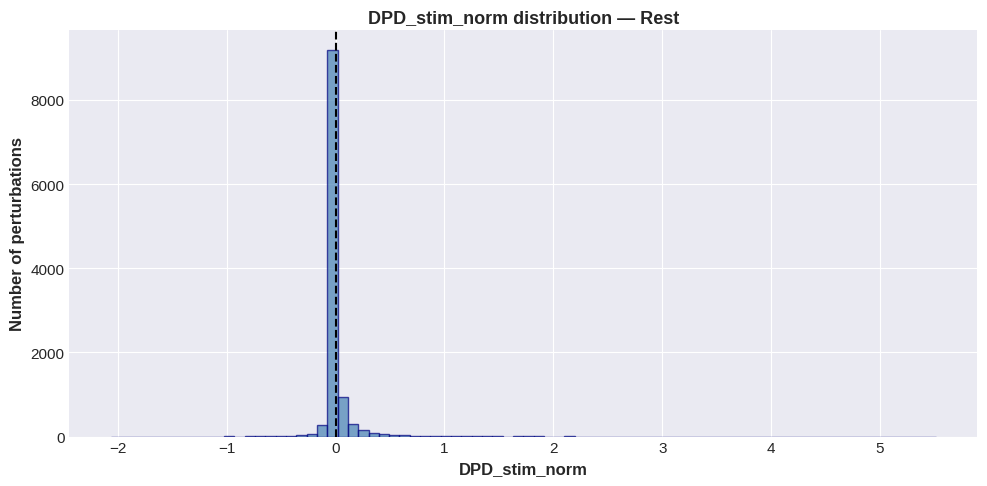

Saved: ../Results/Rest/dpd_stim_histogram_Rest_D1_D2_D3_D4.png


In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(dpd_df['DPD_stim_norm'], bins=80, color='steelblue', edgecolor='navy', alpha=0.7)
ax.axvline(0, color='black', lw=1.5, linestyle='--')
ax.set_xlabel('DPD_stim_norm', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of perturbations', fontsize=12, fontweight='bold')
ax.set_title(f'DPD_stim_norm distribution — {CONDITION}', fontsize=13, fontweight='bold')
plt.tight_layout()
p = os.path.join(OUT_DIR, f'dpd_stim_histogram_{run_tag}.png')
plt.savefig(p, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')


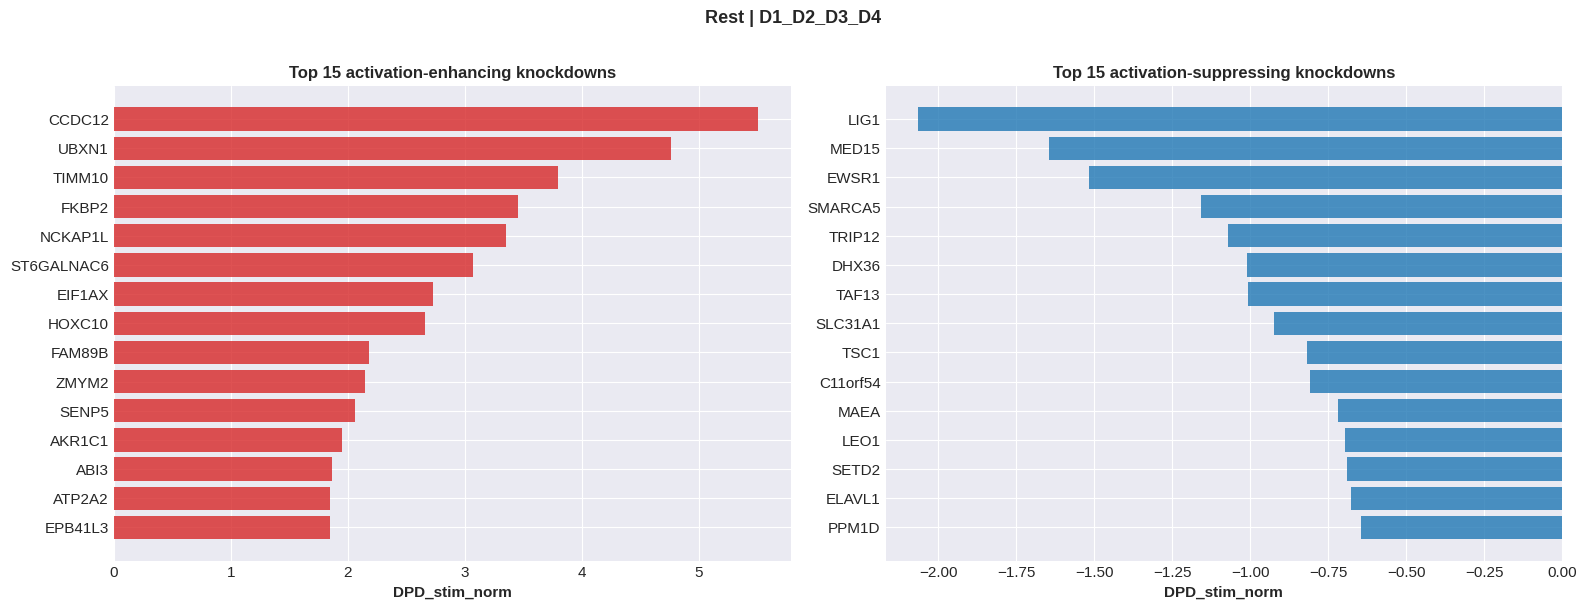

Saved: ../Results/Rest/dpd_top_genes_barchart_Rest_D1_D2_D3_D4.png


In [16]:
top_act = dpd_df.nlargest(TOP_N_BARS, 'DPD_stim_norm')
top_sup = dpd_df.nsmallest(TOP_N_BARS, 'DPD_stim_norm')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.barh(top_act['target_contrast_gene_name'], top_act['DPD_stim_norm'], color='#d62728', alpha=0.8)
ax.set_xlabel('DPD_stim_norm', fontsize=11, fontweight='bold')
ax.set_title(f'Top {TOP_N_BARS} activation-enhancing knockdowns', fontsize=12, fontweight='bold')
ax.invert_yaxis()

ax = axes[1]
ax.barh(top_sup['target_contrast_gene_name'], top_sup['DPD_stim_norm'], color='#1f77b4', alpha=0.8)
ax.set_xlabel('DPD_stim_norm', fontsize=11, fontweight='bold')
ax.set_title(f'Top {TOP_N_BARS} activation-suppressing knockdowns', fontsize=12, fontweight='bold')
ax.invert_yaxis()

plt.suptitle(f'{CONDITION} | {donors_tag}', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
p = os.path.join(OUT_DIR, f'dpd_top_genes_barchart_{run_tag}.png')
plt.savefig(p, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')


In [17]:
if CONDITION != 'Rest':
    # Scatter: DPD_stim_norm vs DPD_btla_norm
    # Colour by n_sig_genes to show which perturbations have large transcriptional footprints
    fig, ax = plt.subplots(figsize=(9, 8))
    sc = ax.scatter(
        dpd_df['DPD_stim_norm'], dpd_df['DPD_btla_norm'],
        c=dpd_df['n_sig_genes'], cmap='viridis', alpha=0.5, s=20)
    ax.axhline(0, color='grey', lw=1, linestyle='--')
    ax.axvline(0, color='grey', lw=1, linestyle='--')
    ax.set_xlabel('DPD_stim_norm (activation axis)', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'DPD_btla_norm (BTLA {BTLA_TIMEPOINT} axis)', fontsize=12, fontweight='bold')
    ax.set_title(f'DPD stim vs BTLA, {CONDITION}\n(colour = n significant DE genes)', fontsize=12, fontweight='bold')
    plt.colorbar(sc, ax=ax, label='n_sig_genes')
    plt.tight_layout()
    p = os.path.join(OUT_DIR, f'dpd_stim_vs_btla_scatter_{run_tag}.png')
    plt.savefig(p, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved: {p}')
else:
    print('Rest condition: DPD_stim vs DPD_btla scatter skipped (no DPD_btla for Rest).')


Rest condition: DPD_stim vs DPD_btla scatter skipped (no DPD_btla for Rest).


### 9. Save

In [18]:
# Main DPD scores table: all perturbations, ranked by DPD_stim_norm
dpd_path = os.path.join(OUT_DIR, f'DPD_scores_{run_tag}.csv')
dpd_df.to_csv(dpd_path, index=False)
print(f'Saved: {dpd_path}')

# Quality-filtered ranked list for sharing (ontarget_significant, no offtarget, n_sig_genes >= 1)
dpd_filtered = dpd_df[
    (dpd_df['ontarget_significant'] == True) &
    (dpd_df['offtarget_flag'] == False) &
    (dpd_df['n_sig_genes'] >= 1)].copy()
dpd_filtered = dpd_filtered.drop_duplicates(subset='target_contrast_gene_name', keep='first')
dpd_filtered = dpd_filtered.reindex(
    dpd_filtered['DPD_stim_norm'].abs().sort_values(ascending=False).index
).reset_index(drop=True)
dpd_filtered.index += 1
ranked_path = os.path.join(OUT_DIR, f'DPD_ranked_filtered_{run_tag}.csv')
dpd_filtered.to_csv(ranked_path, index_label='rank')
print(f'Saved: {ranked_path}  ({len(dpd_filtered):,} genes after quality filter)')

# Stimulation vector (aligned to common gene space)
# For Rest, this saves the Stim8hr-derived v_stim re-aligned to the Rest common gene space,
# so downstream notebooks can load it with the same interface as for Stim conditions.
stim_vec_df = pd.DataFrame({
    'ensembl_id': common_genes,
    'logFC_sig': v_stim_aligned,
    'p_adj': p_adj[ntc_idx],
    'significant': sig_mask[ntc_idx]})
stim_vec_path = os.path.join(OUT_DIR, f'v_stim_{run_tag}.csv')
stim_vec_df.to_csv(stim_vec_path, index=False)
print(f'Saved: {stim_vec_path}')

# Summary stats — btla fields are nan for Rest, consistent with downstream expectations
summary = {'condition': CONDITION, 'donors': str(DONORS), 'run_tag': run_tag,
    'n_perturbations': len(dpd_df), 'n_filtered': len(dpd_filtered),
    'n_sig_vstim_genes': int(sig_mask.sum()),
    'vstim_source': CONDITION if CONDITION != 'Rest' else VSTIM_REF_CONDITION,
    'stim_norm': stim_norm, 'btla_norm': btla_norm,
    'DPD_stim_norm_min': float(dpd_df['DPD_stim_norm'].min()),
    'DPD_stim_norm_max': float(dpd_df['DPD_stim_norm'].max()),
    'DPD_btla_norm_min': float(dpd_df['DPD_btla_norm'].min()) if CONDITION != 'Rest' else np.nan,
    'DPD_btla_norm_max': float(dpd_df['DPD_btla_norm'].max()) if CONDITION != 'Rest' else np.nan,
    'n_positive_stim': int((dpd_df['DPD_stim_norm'] > 0).sum()),
    'n_negative_stim': int((dpd_df['DPD_stim_norm'] < 0).sum())}
pd.DataFrame([summary]).to_csv(os.path.join(OUT_DIR, f'summary_{run_tag}.csv'), index=False)
print(f'Saved: {os.path.join(OUT_DIR, f"summary_{run_tag}.csv")}')

print(f'\nDone, {run_tag}')
print(f'Outputs in: {OUT_DIR}')


Saved: ../Results/Rest/DPD_scores_Rest_D1_D2_D3_D4.csv
Saved: ../Results/Rest/DPD_ranked_filtered_Rest_D1_D2_D3_D4.csv  (6,017 genes after quality filter)
Saved: ../Results/Rest/v_stim_Rest_D1_D2_D3_D4.csv
Saved: ../Results/Rest/summary_Rest_D1_D2_D3_D4.csv

Done, Rest_D1_D2_D3_D4
Outputs in: ../Results/Rest
